# The notebook contains three ML models for landslide susceptibility mapping: Random Forest (RF), Logistic Regression (LR), Support Vector Machine (SVM) and Extreme Gradient Bossting (XGBoost)without climate variables 


##  Machine Learning & Optimization Toolkit


### 1.  Machine Learning Models 

 * **`RandomForestClassifier`:** **Ensemble Model.** A strong, reliable model that uses many "decision trees" to make accurate predictions.
 * **`SVC` (Support Vector Machine):** **Boundary Finder.** Creates the best separation line or curve between different classes in the data.
 * **`LogisticRegression`:** **Simple Classifier.** A fast model used mainly for "Yes/No" or binary predictions.
 * **`XGBClassifier`:** **Top Performer.** An extremely fast and accurate model often used when high prediction performance is critical.

### 2. Setting up and Evaluation 

 * **`Pipeline`:** **Automated Steps.** Links multiple processes (like scaling and modeling) into one reliable workflow.
 * **`StandardScaler`:** **Data Normalizer.** Puts all numerical data on the same scale so no feature is unfairly favored.
 * **`ColumnTransformer`:** **Selective Prep.** Lets you apply different preprocessing steps to different columns (e.g., scale numbers but encode text).
 * **`GridSearchCV`:** **Exhaustive Search.** Checks every combination of model settings you give it to find the very best setup.
 * **`cross_val_score`:** **Reliability Tester.** Tests a model on many different data slices to get a stable, trustworthy performance score.
 * **`classification_report`:** **Detailed Results.** Prints a full summary of model quality (precision, recall, etc.).
 * **`cohen_kappa_score`:** **Agreement Check.** Measures how well the model agrees with the truth, factoring out lucky guesses.
 * **`RocCurveDisplay`:** **Performance Visualizer.** Plots the ROC curve to visually show the model's predictive power.

### 3.  Efficient Global Optimization (Bayesian model) 

 * **`gp_minimize`:** **The Smart Searcher.** The main function for **Bayesian optimization**; it uses probability to intelligently guess the best next setting to test, saving time.
 * **`Integer`, `Real`, `Categorical`:** **Define Boundaries.** Used to set the range and type of values that the optimizer should search for each model setting.
 * **`StratifiedKFold`:** **Balanced Splits.** Ensures that every test group during cross-validation has the exact same mix of classes as the original data.

In [1]:
import os # Import operating system module for file system interaction
import matplotlib.pyplot as plt # Import for plotting (e.g., ROC curves, maps)
import geopandas # Import for working with geospatial vector data (though not heavily used here)
import pandas as pd # Import for data manipulation and analysis (e.g., DataFrames)
import seaborn as sn # Import for statistical data visualization (not explicitly used but often useful)
import rasterio.plot # Import for raster plotting utility (often used with rasterio)
from rasterio.plot import show
from pyspatialml import Raster
import numpy as np # Import for numerical operations and array handling
import matplotlib as mpl # Import for general Matplotlib configuration
from tempfile import NamedTemporaryFile # Import for creating temporary files
import warnings # Import for managing warnings 
warnings.filterwarnings('ignore') # Suppress all warnings to keep the output clean

In [2]:
import os # Import operating system module for file system interaction
import matplotlib.pyplot as plt # Import for plotting (e.g., ROC curves, maps)
import geopandas # Import for working with geospatial vector data (though not heavily used here)
import pandas as pd # Import for data manipulation and analysis (e.g., DataFrames)
import seaborn as sn # Import for statistical data visualization (not explicitly used but often useful)
import rasterio.plot # Import for raster plotting utility (often used with rasterio)
from rasterio.plot import show
import numpy as np # Import for numerical operations and array handling
import matplotlib as mpl # Import for general Matplotlib configuration
from tempfile import NamedTemporaryFile # Import for creating temporary files
import warnings # Import for managing warnings
warnings.filterwarnings('ignore') # Suppress all warnings to keep the output clean

In [3]:
# Install the scikit-optimize library, which is used later for Bayesian optimization (EGO)
!pip install scikit-optimize
from skopt import Optimizer # Import the Optimizer class from scikit-optimize

Setting up the working directory:

In [4]:
os.chdir(r'/workspace/VY') # Set the current working directory to the 'VY' area data

Loading the preprocessed landslide presence/absebce points

In [5]:
# IF you drop any predictor in the previous script, load 'sample_points_VY(remove_collerated_data).csv' instead of 'sample_points.csv'
data=pd.read_csv('sample_points(remove_collerated_data).csv')

In [6]:
data.head() # Display the first few rows of the data to inspect its structure

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,roughness,slope,aspect,profile,planform,Landslide
0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.63,1.57,1.06,1.00,0.83,1
1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,1.26,3.34,0.88,0.98,1.12,1
2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,0.61,1.57,0.69,0.98,1.12,1
3,3.77,0.00,2.39,1.86,1.26,3.57,0.41,0.13,0.78,1.13,1.09,1.63,1.57,1.06,1.06,1.12,1
4,3.77,2.88,1.07,1.86,1.41,3.57,3.22,0.13,0.78,1.13,1.09,1.63,0.39,1.25,0.98,1.12,1


In [7]:
data.describe() # Display summary statistics of the data columns

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,roughness,slope,aspect,profile,planform,Landslide
count,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,1.667370,1.335747,1.168783,1.105162,1.054416,1.748539,0.942338,14.178295,1.045195,1.009334,1.039075,1.258312,1.633068,0.999237,1.001006,1.011932,0.500000
std,1.594624,1.042655,0.704809,0.536668,0.343030,1.471553,1.001584,6.353619,0.361686,0.187408,0.219737,0.467696,1.091102,0.225299,0.051472,0.125328,0.500406
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.560000,1.070000,0.460000,1.010000,0.060000,0.410000,17.250000,0.780000,0.920000,1.090000,0.610000,0.390000,0.880000,0.980000,0.830000,0.000000
50%,0.930000,1.630000,1.070000,1.020000,1.010000,1.890000,0.520000,17.250000,0.780000,1.130000,1.090000,1.630000,1.570000,1.060000,0.980000,1.060000,0.500000
75%,3.770000,1.630000,1.070000,1.860000,1.260000,3.570000,0.770000,17.250000,1.320000,1.130000,1.090000,1.630000,1.570000,1.120000,1.000000,1.120000,1.000000
max,3.770000,4.470000,2.390000,1.860000,1.410000,3.570000,3.220000,17.250000,1.690000,1.130000,1.140000,2.020000,3.340000,1.250000,1.060000,1.120000,1.000000


In [8]:
# List of predictor raster file names (geospatial layers influencing landslide susceptibility)
predictors = ['elevation.tif', 'lulc.tif', 'ndvi.tif', 'ndwi.tif', 'river.tif', 'road.tif', 'lithology.tif', 'lithology_boundary.tif', 'fault.tif', 'twi.tif', 'spi.tif', 'roughness.tif', 'slope.tif', 'aspect.tif', 'profile.tif', 'planform.tif']

In [9]:
print(f"Number of predictor: {len(predictors)}") # Print the total count of predictor variables

Number of predictor: 16


making a raster stack out of predictors

In [10]:
stack = Raster(predictors)

**Make sure all predictor files have the same extend in order for the stack to work!**

stack = Raster(predictors) # Create a Raster stack object from the list of predictor files

In [11]:
stack.names # when it is succesfully stacked, name of all predictors will appear here

dict_keys(['elevation', 'lulc', 'ndvi', 'ndwi', 'river', 'road', 'lithology', 'lithology_boundary', 'fault', 'twi', 'spi', 'roughness', 'slope', 'aspect', 'profile', 'planform'])

Plotting variables

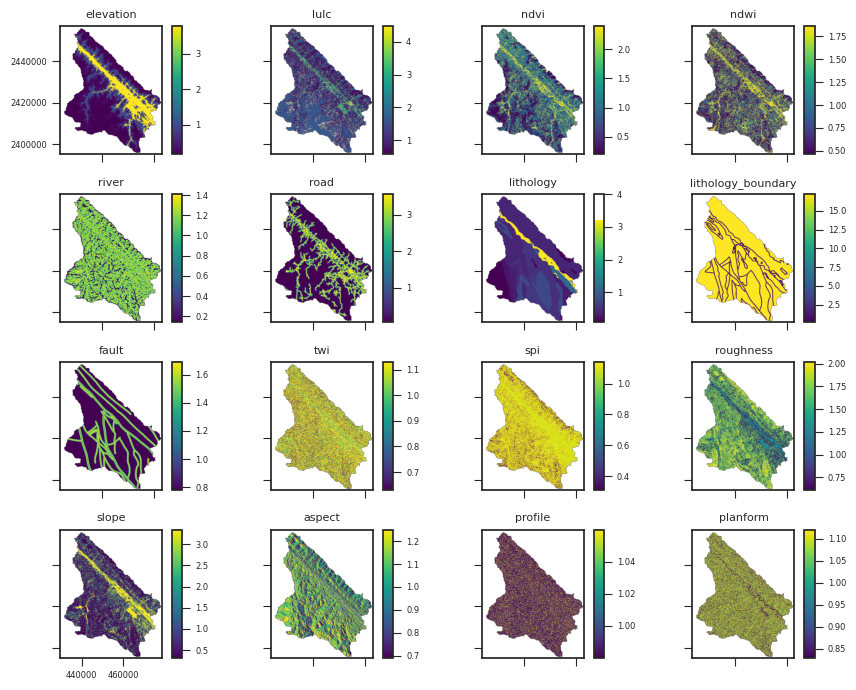

In [12]:
mpl.style.use('seaborn-v0_8-ticks') # Set the Matplotlib style, the style used here is 'seaborn-v0_8-ticks'
axs = stack.plot(figsize=(9, 7)) # Plot all rasters in the stack
ax = axs.flatten()[6] # Get the 7th subplot (index 6)
im = ax.images # Get the image object
im[0].colorbar.set_ticks([1,2,3,4]) # Set custom colorbar ticks for the 7th plot (likely a categorical map)
ax = axs.flatten()[8] # Get the 9th subplot (index 8)
ax.tick_params(axis='x', labelrotation=65) # Rotate x-axis labels for better readability on the 9th plot

plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plo

# Importing packages for Machine Learning

In [13]:
!pip install xgboost 

In [14]:
from sklearn.preprocessing import StandardScaler # Used for standardizing (scaling) numerical features
from sklearn.pipeline import Pipeline # Used to chain multiple processing steps (like scaling + classification)
from sklearn.model_selection import train_test_split # Used to split data into training and testing sets
from sklearn.metrics import make_scorer, accuracy_score # Used to create a scoring function based on accuracy
from sklearn.model_selection import GridSearchCV # Used for exhaustive search over specified parameter values
from sklearn.compose import ColumnTransformer # Used to apply different transformations to different columns
from sklearn.preprocessing import OneHotEncoder # Used for one-hot encoding categorical features (not explicitly used below, but imported)
from sklearn.model_selection import cross_validate, KFold # Import cross_validate and KFold for cross-validation
from sklearn.model_selection import cross_val_score # Import for cross-validation scoring
# Machine Learnig models
from sklearn.ensemble import RandomForestClassifier # Random Forest classifier model
from sklearn.svm import SVC # Support Vector Machine classifier model
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier model
from xgboost import XGBClassifier # Import the XGBoost classifier

In [15]:
# index of numerical features from the dataset
# This defines which columns in the training data will be scaled by StandardScaler
numerical_features = [0, 1, 2, 3, 4, 5, 6] 

In [16]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features)]) # Define a ColumnTransformer to apply StandardScaler only to the specified numerical features

Separating features from class labels

In [17]:
X = data.loc[:, stack.names] # Select all columns that correspond to the raster stack names as features (X)

In [18]:
X[:3] # Display the first three rows of the feature data

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,roughness,slope,aspect,profile,planform
0,3.77,0.56,1.07,1.02,1.41,3.57,0.41,17.25,0.78,1.13,1.09,1.63,1.57,1.06,1.00,0.83
1,3.77,4.47,2.39,1.86,1.01,3.57,1.12,1.24,0.78,1.13,1.09,1.26,3.34,0.88,0.98,1.12
2,0.93,2.88,1.07,1.02,1.26,0.20,0.41,17.25,0.78,1.13,1.14,0.61,1.57,0.69,0.98,1.12


Our labels

In [19]:
y = data["Landslide"] # Select the 'Landslide' column as the target labels (y)

In [20]:
y[:3] # Display the first three labels

0    1
1    1
2    1
Name: Landslide, dtype: int64

Splitting our data into a training (70% of the data) and a testing set (30%), stratified after classes, so that we get the same amount of landslide and non-landslide samples in both sets. Random_sate= 42 for reproducebility

In [21]:
# Split X and y into training (70%) and testing (30%) sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # Initial split using a 30% ratio 

# It is also possible to manually split the dataset into training data and testing:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=[type here], random_state=42, stratify=y) # Final split using a fixed number of samples for the test set, ensuring class balance (stratify=y)

In [22]:
X_test.shape # Check the dimensions (rows, columns) of the test feature set

(185, 16)

Checking the number of points in testing and training data

In [23]:
X_train.shape # Check the dimensions of the training feature set

(431, 16)

In [24]:
X_test.shape # Check the dimensions of the test feature set (re-checked)

(185, 16)

## Random Forest model

In [25]:
# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(accuracy_score) # Define accuracy as the scoring metric for GridSearch

In [26]:
# Create the  grid for hyperparametertuning
grid_rf = {'classifier__n_estimators': [20],
           'classifier__max_features': ['sqrt']}
print(grid_rf)

{'classifier__n_estimators': [20], 'classifier__max_features': ['sqrt']}


In [27]:
# Create a classifier
rf = RandomForestClassifier(random_state=42)

 "Pipeline" is for making workflow with standardization and classification in a few lines of code

In [28]:
rf_flow = Pipeline([
    ('preproc', preprocessor), # Step 1: Apply preprocessing (StandardScaler on numerical features)
    ('classifier', rf) # Step 2: Apply the Random Forest classifier
])

In [29]:
# Instantiate the grid search model with 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42) # Define 10-fold cross-validation strategy
model_rf = GridSearchCV(rf_flow, param_grid = grid_rf, cv = kfold, scoring=acc_scorer) # Setup GridSearch

In [30]:
model_rf.fit(X_train, y_train) # Train the GridSearch model (which internally runs CV for each parameter combination)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_features': ['sqrt'], 'classifier__n_estimators': [20]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(a...hod='predict')
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

Best parameters from the grid search

In [31]:
model_rf.best_params_ # Display the hyperparameters that yielded the best score during cross-validation

{'classifier__max_features': 'sqrt', 'classifier__n_estimators': 20}

Using the test data for prediction

In [32]:
y_pred_rf = model_rf.predict(X_test) # Predict class labels on the unseen test data

Printing classification report

In [33]:
from sklearn.metrics import classification_report # Import for detailed classification metrics
print(classification_report(y_test, y_pred_rf, target_names = ['non-landslide', 'landslide'])) # Print precision, recall, f1-score, and support

               precision    recall  f1-score   support

non-landslide       0.81      0.87      0.84        93
    landslide       0.86      0.79      0.82        92

     accuracy                           0.83       185
    macro avg       0.83      0.83      0.83       185
 weighted avg       0.83      0.83      0.83       185



Printing confusion matrix

In [34]:
# from sklearn.metrics import plot_confusion_matrix, accuracy_score, confusion_matrix 
from sklearn.metrics import accuracy_score, confusion_matrix # Import for accuracy and confusion matrix
print(confusion_matrix(y_test, y_pred_rf)) # Print the raw confusion matrix (True Negatives, False Positives, False Negatives, True Positives)

[[81 12]
 [19 73]]


Doing it in a better visual way

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay # Import utility for plotting the confusion matrix

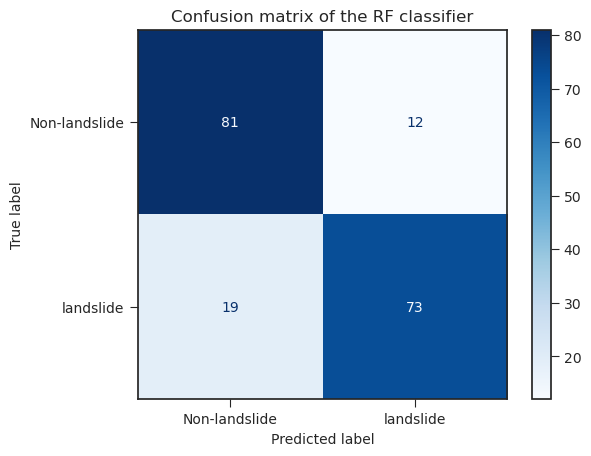

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, 
                                        cmap="Blues", # Use a blue color map
                                        display_labels=["Non-landslide", "landslide"]) # Set human-readable class labels

plt.title('Confusion matrix of the RF classifier') # Set the plot title
plt.show() # Display the plot

Printing overall accuracy (all the correctly classified samples divided by the total number of samples)

In [37]:
from sklearn.metrics import accuracy_score # Duplicate import
print(accuracy_score(y_test, y_pred_rf)) # Print the overall accuracy score

0.8324324324324325


Checking how our model is different from a classification created by a random process

In [38]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred_rf)) # Print Cohen's Kappa score for RF

0.6647179187372113


Plotting ROC_AUC

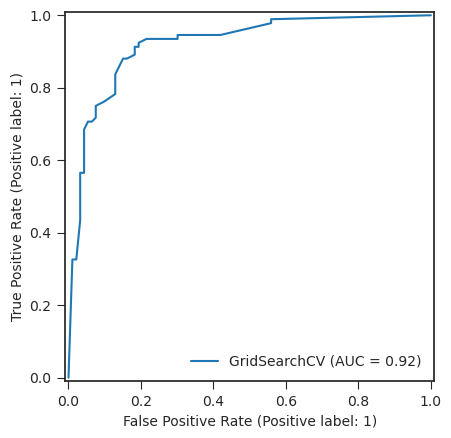

In [39]:
from sklearn import metrics # Import the metrics module
from sklearn.metrics import RocCurveDisplay # Import utility for plotting the ROC curve

RocCurveDisplay.from_estimator(model_rf, X_test, y_test) # Plot the Receiver Operating Characteristic (ROC) curve
plt.show() # Display the plot

## Support Vector Machine model

In [40]:
# Define the hyperparameter grid for the SVM GridSearch
param_grid_SVM = [
  {'classifier__C': [1], 'classifier__gamma': [1, 'scale'], 'classifier__kernel': ['rbf']}, # Explore different C, gamma, and kernel='rbf'
]

In [41]:
## Create a model

# Define the SVM pipeline: Scaling followed by SVC
svm_flow = Pipeline(steps=[('standardscaler', StandardScaler()),('classifier', SVC(probability=True, gamma='auto'))])

# Instantiate the grid search model with 10-fold cross-validation
inner = KFold(n_splits=10, shuffle=True, random_state=42) # Reuse the kfold strategy
model_svm = GridSearchCV(svm_flow, param_grid = param_grid_SVM, cv = inner, scoring=acc_scorer) # Setup GridSearch

# Fit the grid search to the data
model_svm.fit(X_train, y_train) # Train the SVM GridSearch model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [1], 'classifier__gamma': [1, 'scale'], 'classifier__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(a...hod='predict')
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callab

In [42]:
model_svm.best_params_ # Display the best parameters found for SVM

{'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

In [43]:
y_pred_svm = model_svm.predict(X_test) # Predict class labels using the best SVM model

In [44]:
print(classification_report(y_test, y_pred_svm, target_names = ['non-landslide', 'landslide'])) # Print classification report for SVM


               precision    recall  f1-score   support

non-landslide       0.78      0.89      0.83        93
    landslide       0.87      0.74      0.80        92

     accuracy                           0.82       185
    macro avg       0.82      0.82      0.81       185
 weighted avg       0.82      0.82      0.82       185



In [45]:
print(accuracy_score(y_test, y_pred_svm)) # Print overall accuracy for SVM

0.8162162162162162


In [46]:
print(cohen_kappa_score(y_test, y_pred_svm)) # Print Cohen's Kappa score for SVM

0.6321207158732016


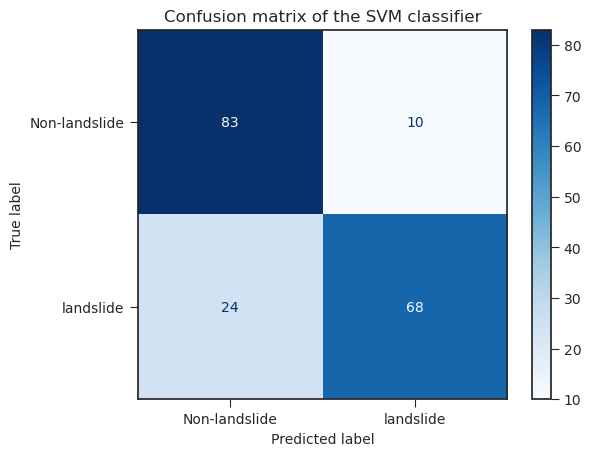

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"]) # Plot the SVM confusion matrix

plt.title('Confusion matrix of the SVM classifier')
plt.show()

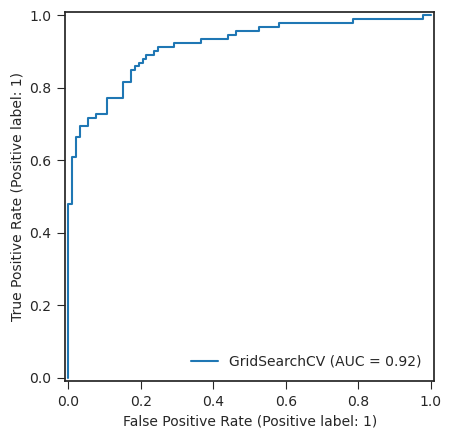

In [48]:
RocCurveDisplay.from_estimator(model_svm, X_test, y_test) # Plot the ROC curve for SVM
plt.show()

## Logistic Regression model

In [49]:
# Define the hyperparameter grid for Logistic Regression GridSearch
param_grid_lr = [
  {'classifier__C': [0.001], 'classifier__solver': ['liblinear'], 'classifier__penalty': ['l2']}, # Solver: liblinear, Penalty: L2, C: 0.001
  {'classifier__C': [0.001], 'classifier__solver': ['lbfgs'], 'classifier__penalty': ['l2']}, # Solver: lbfgs, Penalty: L2, C: 0.001
 ]

In [50]:
lr = LogisticRegression(random_state=42) # Create a Logistic Regression instance
# Instantiate the grid search model

# Define the LR pipeline: Preprocessing followed by LR
lr_flow = Pipeline([
    ('preproc', preprocessor),
    ('classifier', lr)
])

# Instantiate the grid search model with 10-fold cross-validation
model_lr = GridSearchCV(lr_flow, param_grid = param_grid_lr, cv = inner, scoring=acc_scorer)

# Fit the grid search to the data
model_lr.fit(X_train, y_train) # Train the LR GridSearch model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.001], 'classifier__penalty': ['l2'], 'classifier__solver': ['liblinear']}, {'classifier__C': [0.001], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(a...hod='predict')
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`

In [51]:
model_lr.best_params_ # Display the best parameters found for LR

{'classifier__C': 0.001,
 'classifier__penalty': 'l2',
 'classifier__solver': 'liblinear'}

Creating the final LR classifier with the found hyperparameters

In [52]:
y_pred_lr = model_lr.predict(X_test) # Predict class labels using the best LR model

In [53]:
print(classification_report(y_test, y_pred_lr, target_names = ['non-landslide', 'landslide'])) # Print classification report for LR

               precision    recall  f1-score   support

non-landslide       0.76      0.94      0.84        93
    landslide       0.91      0.70      0.79        92

     accuracy                           0.82       185
    macro avg       0.84      0.82      0.81       185
 weighted avg       0.83      0.82      0.81       185



In [54]:
round(accuracy_score(y_test, y_pred_lr), 4) # Print and round the overall accuracy for LR

0.8162

In [55]:
print(cohen_kappa_score(y_test, y_pred_lr)) # Print Cohen's Kappa score for LR

0.6319485078993563


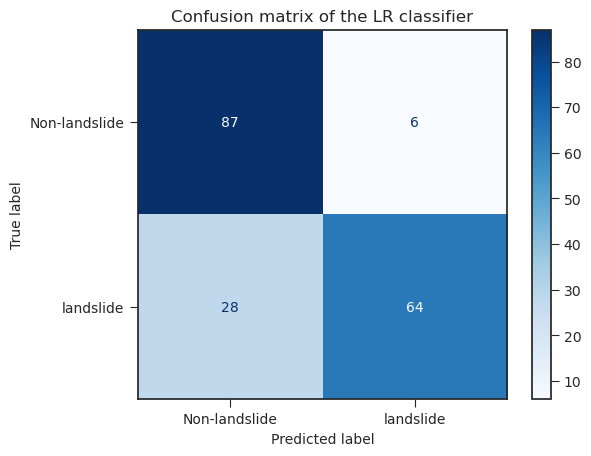

In [56]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"]) # Plot the LR confusion matrix

plt.title('Confusion matrix of the LR classifier')
plt.show()

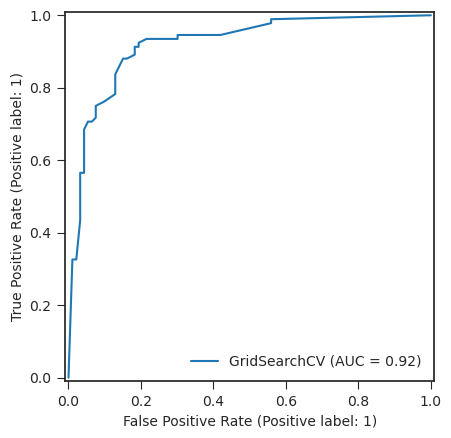

In [57]:
#metrics.plot_roc_curve(model_lr, X_test, y_test)  
RocCurveDisplay.from_estimator(model_rf, X_test, y_test)
plt.show() 

##  XGBoost

In [58]:
# Create the grid for hyperparameter tuning for XGBoost
param_grid_xgb = {
    'classifier__learning_rate': [0.01],
    'classifier__max_depth': [7],
    'classifier__n_estimators': [100],
    'classifier__gamma': [0.5],
    'classifier__subsample': [1.0],
    'classifier__colsample_bytree': [1.0],
    'classifier__reg_alpha': [0],
    'classifier__reg_lambda': [ 5.0],
    'classifier__scale_pos_weight': [1]
}

In [59]:
# Create a classifier
xgb = XGBClassifier(random_state=42)

In [60]:
# "Pipeline" is for making workflow with standardization and classification in a few lines of code
# Define the XGBoost pipeline: Preprocessing followed by XGBoost
xgb_flow = Pipeline([
    ('preproc', preprocessor),
    ('classifier', xgb)
])

In [61]:
# Instantiate the grid search model with 10-fold cross-validation
# Use the same kfold strategy defined earlier
model_xgb = GridSearchCV(xgb_flow, param_grid=param_grid_xgb, cv=kfold, scoring=acc_scorer)

In [62]:
# Fit the grid search model
model_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [1.0], 'classifier__gamma': [0.5], 'classifier__learning_rate': [0.01], 'classifier__max_depth': [7], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(a...hod='predict')
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validate

In [63]:
# Best parameters from the grid search
print("XGBoost Best Parameters:", model_xgb.best_params_)

XGBoost Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0.5, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__n_estimators': 100, 'classifier__reg_alpha': 0, 'classifier__reg_lambda': 5.0, 'classifier__scale_pos_weight': 1, 'classifier__subsample': 1.0}


In [64]:
# Using the test data for prediction
y_pred_xgb = model_xgb.predict(X_test)

In [65]:
# Printing classification report
print(classification_report(y_test, y_pred_xgb, target_names=['non-landslide', 'landslide']))

               precision    recall  f1-score   support

non-landslide       0.86      0.82      0.84        93
    landslide       0.82      0.87      0.85        92

     accuracy                           0.84       185
    macro avg       0.84      0.84      0.84       185
 weighted avg       0.84      0.84      0.84       185



In [66]:
# Printing confusion matrix
print(confusion_matrix(y_test, y_pred_xgb))

[[76 17]
 [12 80]]


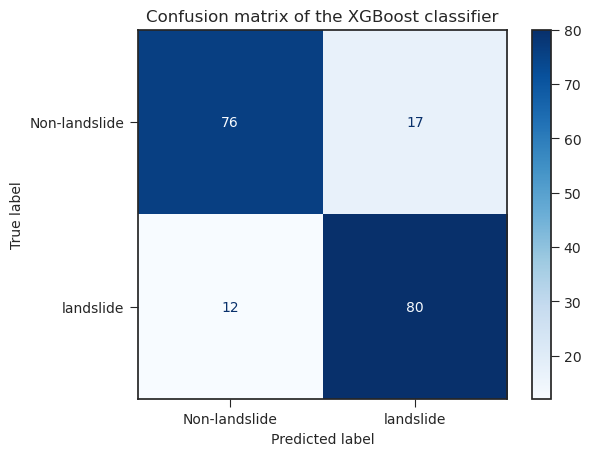

In [67]:
# Plotting confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"])
plt.title('Confusion matrix of the XGBoost classifier')
plt.show()

In [68]:
# Printing overall accuracy
print(accuracy_score(y_test, y_pred_xgb))

0.8432432432432433


In [69]:
# Checking how our model is different from a classification created by a random process
print(cohen_kappa_score(y_test, y_pred_xgb))

0.6865689081030555


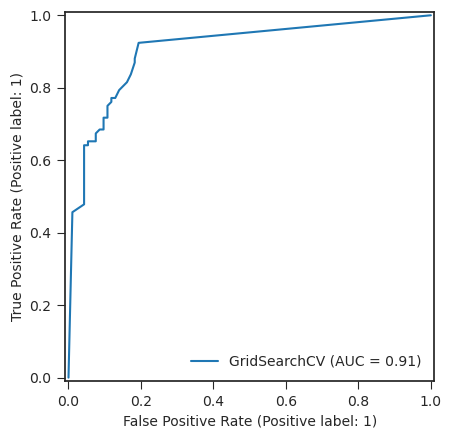

In [70]:
# Plotting ROC_AUC
RocCurveDisplay.from_estimator(model_xgb, X_test, y_test)
plt.show() 

## Plotting ROC curves for the three models

In [71]:
from sklearn.metrics import roc_auc_score, roc_curve, auc # Import for calculating ROC and AUC

In [72]:
# Random Forest ROC calculation
pred_prob_rf=model_rf.predict_proba(X_test)[:,1] # Get probability of the positive class (landslide)
fpr1, tpr1, threshold1 = roc_curve(y_test, pred_prob_rf, pos_label=1) # Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
# AUC score that summarizes the ROC curve
roc_auc1 = auc(fpr1, tpr1)

In [73]:
# SVM ROC calculation
pred_prob_svm=model_svm.predict_proba(X_test)[:,1] # Get probability of the positive class
fpr2, tpr2, threshold2 = roc_curve(y_test, pred_prob_svm, pos_label=1)
# AUC score that summarizes the ROC curve
roc_auc2 = auc(fpr2, tpr2)

In [74]:
# XGBoost ROC calculation
pred_prob_xgb=model_xgb.predict_proba(X_test)[:,1] # Get probability of the positive class
fpr4, tpr4, threshold4 = roc_curve(y_test, pred_prob_xgb, pos_label=1)
roc_auc4 = auc(fpr4, tpr4)

In [75]:
# Logistic Regression ROC calculation
pred_prob_lr=model_lr.predict_proba(X_test)[:,1] # Get probability of the positive class
fpr3, tpr3, threshold3 = roc_curve(y_test, pred_prob_lr, pos_label=1)
roc_auc3 = auc(fpr3, tpr3)

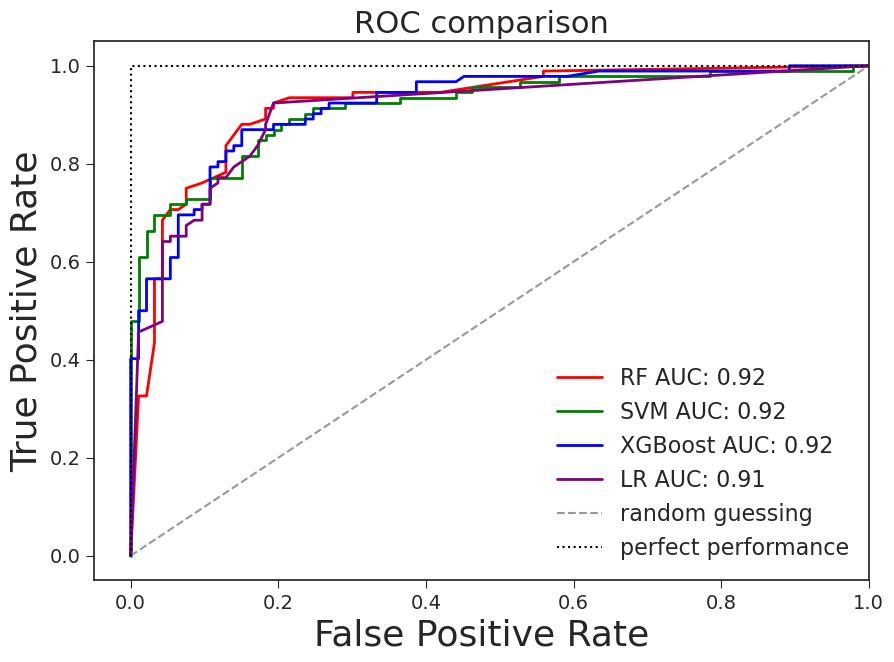

In [76]:
# AUC score that summarizes the ROC curve
f, ax = plt.subplots(figsize=(10,7))

# Random Forest
plt.plot(fpr1, tpr1, color='red', lw=2, 
         label='RF AUC: {:.2f}'.format(roc_auc1))

# SVM
plt.plot(fpr2, tpr2, color='green', lw=2, 
         label='SVM AUC: {:.2f}'.format(roc_auc2))

# Logistic Regression
plt.plot(fpr3, tpr3, color='blue', lw=2, 
         label='XGBoost AUC: {:.2f}'.format(roc_auc3))

# XGBoost 
plt.plot(fpr4, tpr4, color='purple', lw=2, 
         label='LR AUC: {:.2f}'.format(roc_auc4))

# Reference lines
plt.plot([0, 1], [0, 1], linestyle='--', color=(0.6, 0.6, 0.6), label='random guessing')
plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='black', label='perfect performance')

# Axis limits and labels
plt.xlim([-.05, 1.0])
plt.ylim([-.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=26)
plt.ylabel('True Positive Rate', fontsize=26)
plt.title('ROC comparison', fontsize=22)

# Legend and ticks
plt.legend(loc="lower right", fontsize=16)
plt.xticks(ticks=np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(ticks=np.arange(0, 1.1, 0.2), fontsize=14)

# Save if needed
plt.savefig(r'/workspace/fig/VY/AUC.png', bbox_inches='tight', dpi=600)

plt.show()



## EGO (Bayesian optimization) 


In [77]:
from skopt import Optimizer # Duplicate import
from sklearn.model_selection import cross_val_score # Duplicate import
from skopt import gp_minimize # Core function for Gaussian Process-based optimization
from skopt.space import Integer, Real, Categorical # Defines the search space for hyperparameters
from skopt.utils import use_named_args # Decorator to easily access hyperparameter names
from sklearn.pipeline import Pipeline # Duplicate import
from sklearn.preprocessing import StandardScaler # Duplicate import
from sklearn.svm import SVC # Duplicate import
from sklearn.metrics import pairwise_distances # Used for calculating distances in SVM setup
import numpy as np # Duplicate import
from sklearn.model_selection import StratifiedKFold # Used to ensure stratified cross-validation
from skopt.callbacks import DeltaXStopper

In [78]:
# --- Fixed CV to reduce noise across all models ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Define 5-fold stratified CV for stability

def neg_cv_auc(estimator):
    # Calculates the mean ROC-AUC score across CV folds and returns the negative mean (since gp_minimize minimizes)
    scores = cross_val_score(estimator, X_train, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    return -scores.mean() # Return negative AUC

In [79]:
# ---- RF SEARCH SPACE ----
# RF
space_rf = [
    Integer(400, 800, name='n_estimators'),        # Number of trees
    Integer(10, 20, name='max_depth'),               # Max depth of each tree
    Categorical(['sqrt', 'log2'], name='max_features'), # Max features to consider for splitting
    Categorical([True], name='bootstrap'),          # Whether bootstrap samples are used
    Integer(2, 5, name='min_samples_leaf'),        # Minimum number of samples required to be at a leaf node
    Integer(2, 5, name='min_samples_split'),       # Minimum number of samples required to split an internal node
]


@use_named_args(space_rf)
def objective_rf(**p):
    # Objective function for RF optimization
    clf = RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        max_features=p['max_features'],
        bootstrap=p['bootstrap'],
        min_samples_leaf=p['min_samples_leaf'],
        min_samples_split=p['min_samples_split'],
        n_jobs=-1,
        random_state=42,
    )
    return neg_cv_auc(clf) # Return negative CV AUC

In [ ]:
# ---- RF BAYESIAN OPT ----
OPT_CALLS = 600
INIT_POINTS_RF = 50  # instead of 100

RNG = 42

res_rf = gp_minimize(
    objective_rf, space_rf,
    n_calls=OPT_CALLS,
    n_initial_points=INIT_POINTS_RF,
    acq_func="EI",      # Expected Improvement acquisition function
    xi=0.001,            # Exploration factor for EI
    acq_optimizer="lbfgs",
    n_restarts_optimizer=15,
    random_state=RNG
)


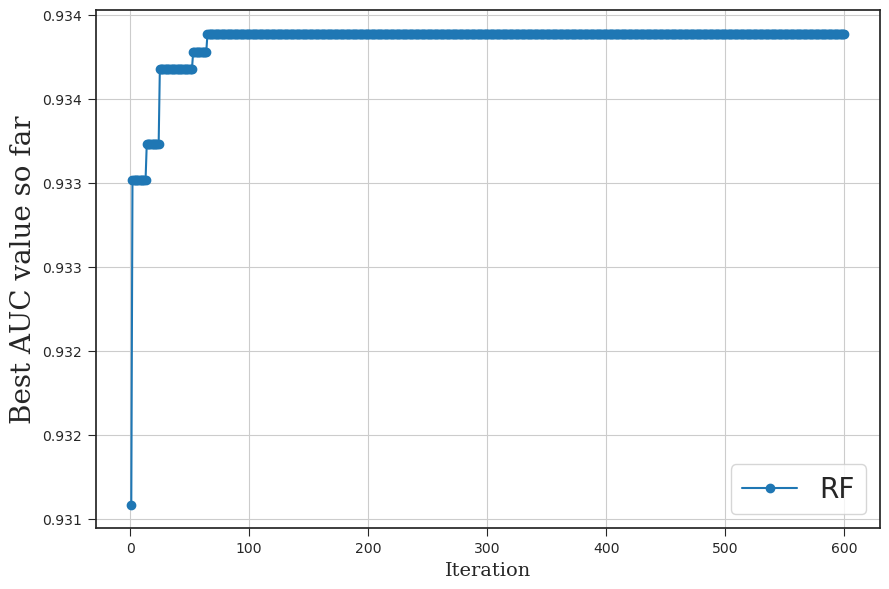

In [92]:
# -------------------- Build & plot convergence curve --------------------
def best_auc_so_far(res):
    auc_vals = -np.array(res.func_vals, dtype=float)
    return np.maximum.accumulate(auc_vals)

rf_curve = best_auc_so_far(res_rf)

# ---- PLOT ----
plt.figure(figsize=(9, 6))
iters = np.arange(1, len(rf_curve) + 1)
plt.plot(iters, rf_curve, marker='o', label="RF")

# Enlarge font sizes (equivalent to Times New Roman)
plt.xlabel("Iteration", fontsize=14, fontfamily='serif')
plt.ylabel("Best AUC value so far", fontsize=20, fontfamily='serif')
# Title removed as requested

# Format Y-axis to 3 decimal places
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.3f}'.format(y)))

# Enlarge legend font size
plt.legend(loc="best", fontsize=20, frameon=True)

plt.grid(True)
plt.tight_layout()
#plt.savefig(r'/workspace/fig/VY/EGO.png', bbox_inches='tight', dpi=600) # Save the convergence plot
plt.show()

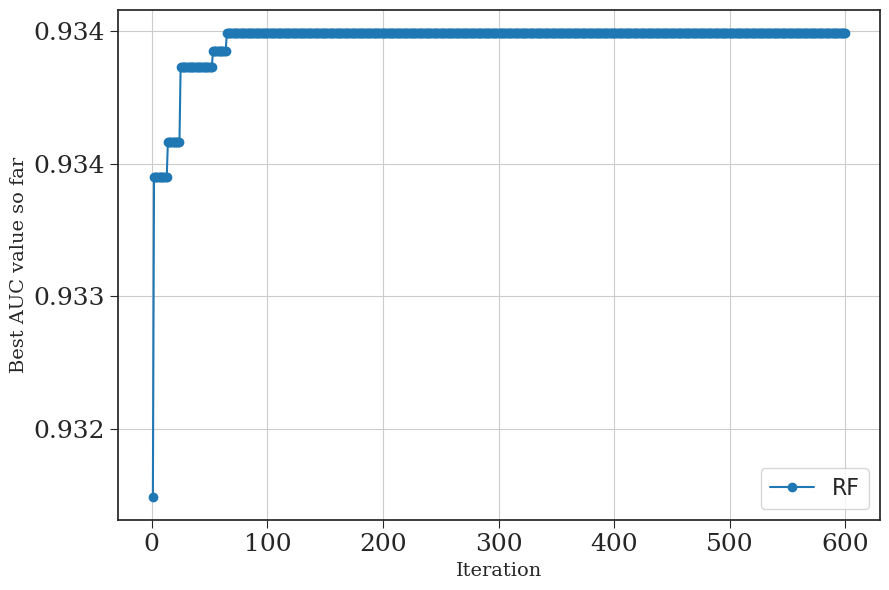

In [96]:
## this section is for testing with different tunning
# -------------------- Build & plot convergence curve --------------------
def best_auc_so_far(res):
    auc_vals = -np.array(res.func_vals, dtype=float)
    return np.maximum.accumulate(auc_vals)

rf_curve = best_auc_so_far(res_rf)

# ---- PLOT ----
plt.figure(figsize=(9, 6))
iters = np.arange(1, len(rf_curve) + 1)
plt.plot(iters, rf_curve, marker='o', label="RF")

# Enlarge font sizes for axis labels (equivalent to Times New Roman)
plt.xlabel("Iteration", fontsize=14, fontfamily='serif')
plt.ylabel("Best AUC value so far", fontsize=14, fontfamily='serif')
# Title removed as requested

# Get current axes
ax = plt.gca()

# Format Y-axis tick labels to 3 decimal places
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.3f}'.format(y)))

# Reduce number of y-axis ticks to avoid overlapping labels
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))  # Adjust nbins to control number of ticks

# Enlarge tick label font size for both axes (manually adjustable)
tick_label_fontsize = 18  # Change this value to adjust tick label size
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize)

# Apply serif font to tick labels
for label in ax.get_xticklabels():
    label.set_fontfamily('serif')
for label in ax.get_yticklabels():
    label.set_fontfamily('serif')

# Enlarge legend font size
plt.legend(loc="best", fontsize=16, frameon=True)

plt.grid(True)
plt.tight_layout()
plt.savefig(r'/workspace/fig/VY/EGO_new.png', bbox_inches='tight', dpi=600) # Save the convergence plot
plt.show()

## External Validation on the dataset outside of our AOI

Reading the data (landslide absence and presence points). The data is unseen by the models, as it comes outside of the AOI, and it has not earlier been used for training or testing

In [84]:
os.chdir(r'/workspace/MCC')# Change the working directory to the MCC area data folder

In [85]:
external_val_data=pd.read_csv('sample_points(remove_collerated_data).csv') # Load the sample points for external validation (MCC)

dropping the columns with climate variables

In [86]:
external_val_data.head() # Inspect the start of the external validation data

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,roughness,slope,aspect,profile,planform,Landslide
0,0.391,0.697,0.530,1.434,0.625,2.360,0.825,83.720001,0.746,0.908,0.751,1.16,1.29,0.886,0.832,0.941,0
1,1.107,0.697,1.132,1.434,1.268,0.372,0.825,83.720001,1.031,1.113,0.864,1.16,1.29,0.839,1.110,0.941,0
2,1.107,0.697,0.530,0.445,1.268,2.360,0.825,83.720001,1.031,1.047,1.080,1.16,1.85,1.217,0.832,1.030,0
3,1.966,0.697,0.530,1.434,1.026,0.372,0.825,83.720001,1.031,0.908,1.080,1.16,1.29,0.886,0.835,0.941,0
4,0.094,0.697,0.530,0.683,1.026,0.200,0.825,7.780000,1.031,0.810,0.864,1.16,1.29,1.383,0.835,0.941,0


In [87]:
external_val_data.describe() # Inspect the summary statistics of the external validation data

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,roughness,slope,aspect,profile,planform,Landslide
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,2.354037,1.272965,1.251149,1.084206,1.033107,1.554650,1.074187,76.613707,1.008486,0.995598,0.990598,1.136084,1.189668,1.029131,1.018051,1.009442,0.500000
std,9.910948,1.074756,0.965205,0.588377,0.255799,1.040375,0.397491,22.497581,0.148521,0.103580,0.137536,0.285051,0.315733,0.253285,0.185217,0.148820,0.500438
min,0.094000,0.697000,0.530000,0.445000,0.444000,0.104000,0.000000,4.060000,0.746000,0.810000,0.751000,0.560000,0.710000,0.653000,0.000000,0.000000,0.000000
25%,0.391000,0.697000,0.530000,0.683000,0.983000,0.200000,0.825000,83.720001,1.031000,0.908000,0.864000,1.160000,0.880000,0.839000,0.832000,0.941000,0.000000
50%,1.107000,0.697000,1.132000,1.434000,1.026000,2.360000,0.825000,83.720001,1.031000,1.047000,1.080000,1.160000,1.290000,0.980000,1.110000,1.030000,0.500000
75%,1.107000,2.225000,1.350250,1.434000,1.268000,2.360000,1.678000,83.720001,1.138000,1.091000,1.080000,1.160000,1.290000,1.383000,1.110000,1.030000,1.000000
max,69.867996,6.568000,5.061000,8.408000,1.268000,2.360000,1.678000,83.720001,1.138000,1.113000,1.230000,2.120000,1.850000,1.383000,1.277000,1.651000,1.000000


In [88]:
external_val_data.info() # Inspect the data types and check for non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   elevation           572 non-null    float64
 1   lulc                572 non-null    float64
 2   ndvi                572 non-null    float64
 3   ndwi                572 non-null    float64
 4   river               572 non-null    float64
 5   road                572 non-null    float64
 6   lithology           572 non-null    float64
 7   lithology_boundary  572 non-null    float64
 8   fault               572 non-null    float64
 9   twi                 572 non-null    float64
 10  spi                 572 non-null    float64
 11  roughness           572 non-null    float64
 12  slope               572 non-null    float64
 13  aspect              572 non-null    float64
 14  profile             572 non-null    float64
 15  planform            572 non-null    float64
 16  Landslid

dropping null values

In [89]:
external_val_data=external_val_data.dropna() # Remove any rows with missing (NaN) values

In [90]:
external_val_data.info() # Re-check the non-null counts after dropping

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   elevation           572 non-null    float64
 1   lulc                572 non-null    float64
 2   ndvi                572 non-null    float64
 3   ndwi                572 non-null    float64
 4   river               572 non-null    float64
 5   road                572 non-null    float64
 6   lithology           572 non-null    float64
 7   lithology_boundary  572 non-null    float64
 8   fault               572 non-null    float64
 9   twi                 572 non-null    float64
 10  spi                 572 non-null    float64
 11  roughness           572 non-null    float64
 12  slope               572 non-null    float64
 13  aspect              572 non-null    float64
 14  profile             572 non-null    float64
 15  planform            572 non-null    float64
 16  Landslid

In [91]:
external_val_data['Landslide'].value_counts() # Check the class balance (number of landslide vs. non-landslide points)

Landslide
0    286
1    286
Name: count, dtype: int64

In [92]:
## stacking rasters to generate the LSM map for the validation area

In [93]:
# List of predictor raster file names for the Validation area. Should match the Study area.
predictors = ['elevation.tif', 'lulc.tif', 'ndvi.tif', 'ndwi.tif', 'river.tif', 'road.tif', 'lithology.tif', 'lithology_boundary.tif', 'fault.tif', 'twi.tif', 'spi.tif', 'roughness.tif', 'slope.tif', 'aspect.tif', 'profile.tif','planform.tif']


In [94]:
stack_val = Raster(predictors) # Create a Raster stack object for the validation area 

In [95]:
stack_val.names

dict_keys(['elevation', 'lulc', 'ndvi', 'ndwi', 'river', 'road', 'lithology', 'lithology_boundary', 'fault', 'twi', 'spi', 'roughness', 'slope', 'aspect', 'profile', 'planform'])

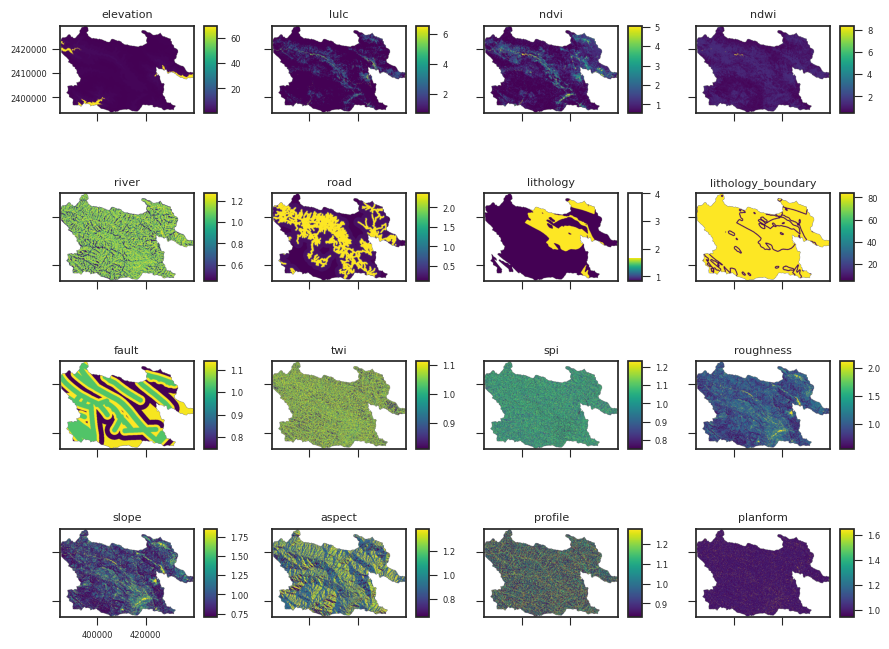

In [96]:
mpl.style.use('seaborn-v0_8-ticks')
axs = stack_val.plot(figsize=(9,  7))
ax = axs.flatten()[6]
im = ax.images
im[0].colorbar.set_ticks([1,2,3,4])
ax = axs.flatten()[8]
ax.tick_params(axis='x', labelrotation=65)

plt.tight_layout()
plt.show()

In [97]:
# index of numerical features from the dataset
numerical_features = [0, 1, 2, 3, 4, 5, 6] # Re-define numerical features (must match the training set)

In [98]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features)]) # Re-define the preprocessor (StandardScaler)

In [99]:
external_val_data['Landslide'].value_counts() # Re-check class balance

Landslide
0    286
1    286
Name: count, dtype: int64

Dividing the data into variables and the labels

In [100]:
X_val = external_val_data.iloc[:, 0:-1] # Select all columns except the last one (assumed to be the label) as features for validation

In [101]:
X_val.head() # Inspect the start of the validation features

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,roughness,slope,aspect,profile,planform
0,0.391,0.697,0.530,1.434,0.625,2.360,0.825,83.720001,0.746,0.908,0.751,1.16,1.29,0.886,0.832,0.941
1,1.107,0.697,1.132,1.434,1.268,0.372,0.825,83.720001,1.031,1.113,0.864,1.16,1.29,0.839,1.110,0.941
2,1.107,0.697,0.530,0.445,1.268,2.360,0.825,83.720001,1.031,1.047,1.080,1.16,1.85,1.217,0.832,1.030
3,1.966,0.697,0.530,1.434,1.026,0.372,0.825,83.720001,1.031,0.908,1.080,1.16,1.29,0.886,0.835,0.941
4,0.094,0.697,0.530,0.683,1.026,0.200,0.825,7.780000,1.031,0.810,0.864,1.16,1.29,1.383,0.835,0.941


In [102]:
y_val = external_val_data["Landslide"] # Select the 'Landslide' column as the target labels for validation

In [103]:
y_val[:3] # Inspect the start of the validation labels

0    0
1    0
2    0
Name: Landslide, dtype: int64

In [104]:
X_val.shape # Check the dimensions of the validation feature set

(572, 16)

## SVM

Predicting the classes of the external validation data with our trained SVM classifier

In [105]:
y_pred_svm_val = model_svm.predict(X_val) # Use the model trained on VY (model_svm) to predict on MCC data (X_val)

Printing overall accuracy

In [106]:
from sklearn.metrics import accuracy_score # Duplicate import
round(accuracy_score(y_val, y_pred_svm_val),4) # Print the overall accuracy for SVM on external data

0.5157

In [107]:
# Checking how our model is different from a classification created by a random process
print(cohen_kappa_score(y_val, y_pred_svm_val)) # Print Cohen's Kappa score for SVM on external data

0.03146853146853146


In [108]:
print(classification_report(y_val, y_pred_svm_val, target_names = ['non-landslide', 'landslide'])) # Print classification report for SVM on external data

               precision    recall  f1-score   support

non-landslide       0.71      0.05      0.10       286
    landslide       0.51      0.98      0.67       286

     accuracy                           0.52       572
    macro avg       0.61      0.52      0.38       572
 weighted avg       0.61      0.52      0.38       572



Plotting confusion matrix

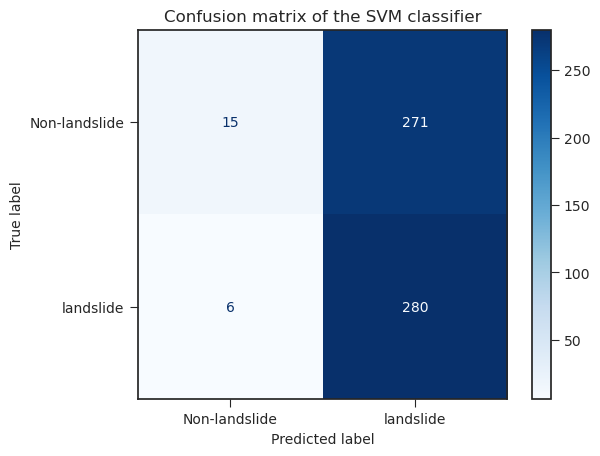

In [109]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_svm_val, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"]) # Plot the confusion matrix for SVM on external data

plt.title('Confusion matrix of the SVM classifier')
plt.show()

Repeating the process with RF and LR

## Random Forest

In [110]:
y_pred_rf_val = model_rf.predict(X_val) # Use the model trained on VY (model_rf) to predict on MCC data (X_val)

In [111]:
from sklearn.metrics import accuracy_score # Duplicate import
round(accuracy_score(y_val, y_pred_rf_val), 4) # Print the overall accuracy for RF on external data

0.6696

In [112]:
print(cohen_kappa_score(y_val, y_pred_rf_val)) # Print Cohen's Kappa score for RF on external data

0.33916083916083917


In [113]:
print(classification_report(y_val, y_pred_rf_val, target_names = ['non-landslide', 'landslide'])) # Print classification report for RF on external data

               precision    recall  f1-score   support

non-landslide       0.64      0.80      0.71       286
    landslide       0.73      0.54      0.62       286

     accuracy                           0.67       572
    macro avg       0.68      0.67      0.66       572
 weighted avg       0.68      0.67      0.66       572



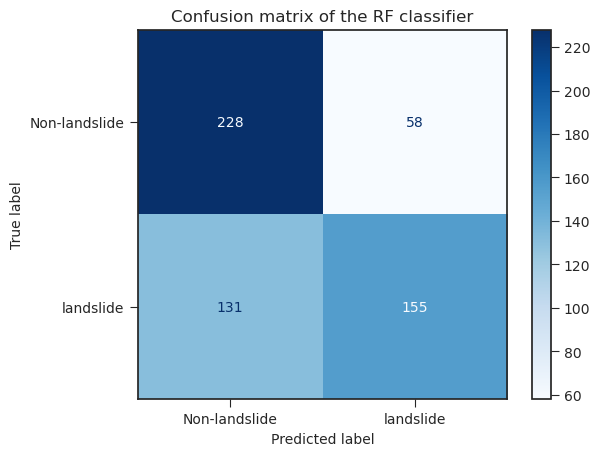

In [114]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf_val, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"]) # Plot the confusion matrix for RF on external data

plt.title('Confusion matrix of the RF classifier')
plt.show()

## Logistic Regression

In [115]:
y_pred_lr_val = model_lr.predict(X_val) # Use the model trained on VY (model_lr) to predict on MCC data (X_val)

In [116]:
from sklearn.metrics import accuracy_score # Duplicate import
round(accuracy_score(y_val, y_pred_lr_val), 4) # Print the overall accuracy for LR on external data

0.6731

In [117]:
print(cohen_kappa_score(y_val, y_pred_lr_val)) # Print Cohen's Kappa score for LR on external data

0.34615384615384615


In [118]:
# NOTE: This line prints the SVM classification report again. Likely a copy-paste error.
print(classification_report(y_val, y_pred_lr_val, target_names = ['non-landslide', 'landslide'])) # Corrected to use y_pred_lr_val

               precision    recall  f1-score   support

non-landslide       0.64      0.80      0.71       286
    landslide       0.73      0.54      0.62       286

     accuracy                           0.67       572
    macro avg       0.69      0.67      0.67       572
 weighted avg       0.69      0.67      0.67       572



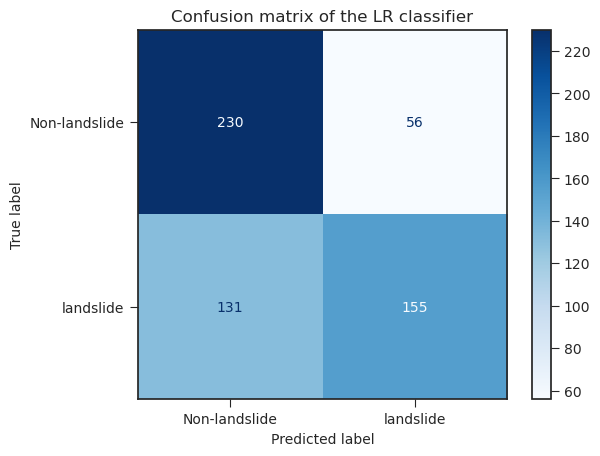

In [119]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr_val, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"]) # Plot the confusion matrix for LR on external data

plt.title('Confusion matrix of the LR classifier')
plt.show()

## XG Boost

In [120]:
# Predicting with the trained XGBoost model
y_pred_xgb_val = model_xgb.predict(X_val) # Use the model trained on VY (model_xgb) to predict on MCC data (X_val)

In [121]:
# Printing overall accuracy
from sklearn.metrics import accuracy_score # Duplicate import
print("XGBoost Validation Accuracy:", round(accuracy_score(y_val, y_pred_xgb_val), 4)) # Print overall accuracy for XGBoost on external data

XGBoost Validation Accuracy: 0.7413


In [122]:
print(cohen_kappa_score(y_val, y_pred_xgb_val)) # Print Cohen's Kappa score for XGBoost on external data

0.4825174825174825


In [123]:
print(classification_report(y_val, y_pred_xgb_val, target_names = ['non-landslide', 'landslide'])) # Print classification report for XGBoost on external data

               precision    recall  f1-score   support

non-landslide       0.82      0.62      0.71       286
    landslide       0.69      0.86      0.77       286

     accuracy                           0.74       572
    macro avg       0.76      0.74      0.74       572
 weighted avg       0.76      0.74      0.74       572



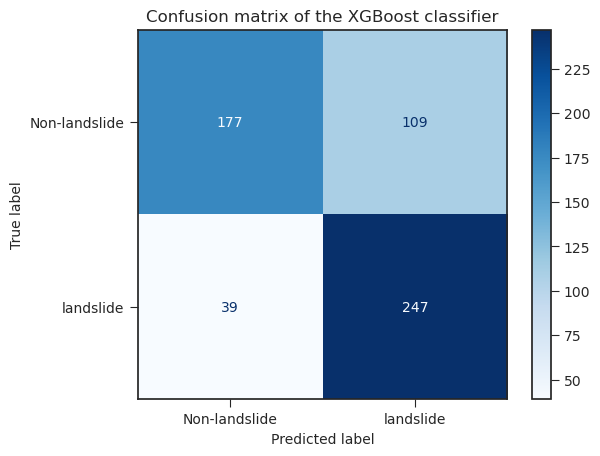

In [124]:
# Plotting confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay # Duplicate import
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_xgb_val, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"])
plt.title('Confusion matrix of the XGBoost classifier')
plt.show()

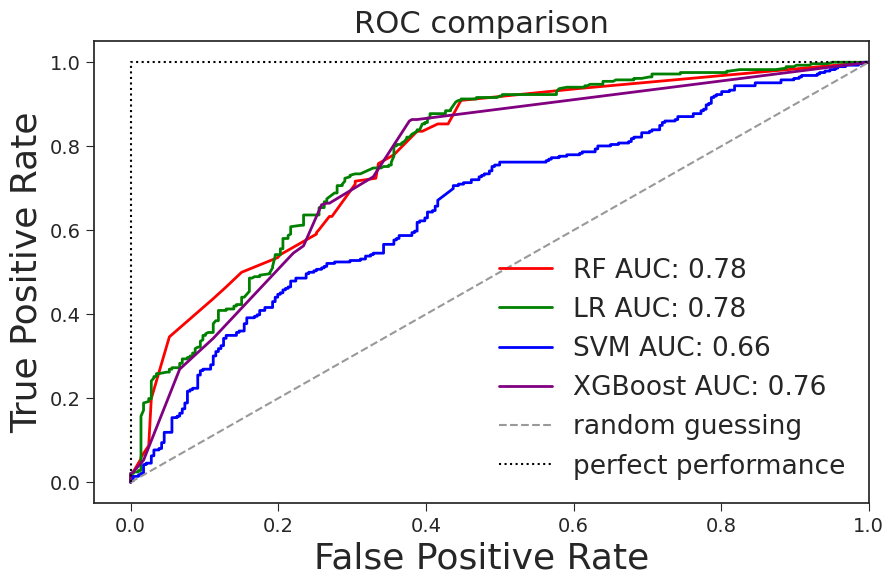

In [125]:
# ====================================================
# ROC curves for 4 ML models on MCC validation area
# (Models were trained on VY area)
# ====================================================

# Random Forest
pred_prob_rf_val = model_rf.predict_proba(X_val)[:, 1] # Get probabilities for RF
fpr1_val, tpr1_val, _ = roc_curve(y_val, pred_prob_rf_val, pos_label=1)
roc_auc1_val = auc(fpr1_val, tpr1_val)

# Logistic Regression (NOTE: Uses fpr2, tpr2, roc_auc2 but is labeled LR in the plot, suggesting variable reuse)
pred_prob_lr_val = model_lr.predict_proba(X_val)[:, 1] # Get probabilities for LR
fpr2_val, tpr2_val, _ = roc_curve(y_val, pred_prob_lr_val, pos_label=1)
roc_auc2_val = auc(fpr2_val, tpr2_val)

# SVM (NOTE: Uses fpr3, tpr3, roc_auc3 but is labeled SVM in the plot)
pred_prob_svm_val = model_svm.predict_proba(X_val)[:, 1] # Get probabilities for SVM
fpr3_val, tpr3_val, _ = roc_curve(y_val, pred_prob_svm_val, pos_label=1)
roc_auc3_val = auc(fpr3_val, tpr3_val)

# XGBoost (Uses fpr4, tpr4, roc_auc4)
pred_prob_xgb_val = model_xgb.predict_proba(X_val)[:, 1] # Get probabilities for XGBoost
fpr4_val, tpr4_val, _ = roc_curve(y_val, pred_prob_xgb_val, pos_label=1)
roc_auc4_val = auc(fpr4_val, tpr4_val)

# Plot ROC curves for MCC validation
plt.figure(figsize=(10,6))
# RF plot
plt.plot(fpr1_val, tpr1_val, color ='red', lw=2, label= 'RF AUC: {:.2f}'.format(roc_auc1_val))
# LR plot (using fpr2/auc2 for LR)
plt.plot(fpr2_val, tpr2_val, color ='green', lw=2, label='LR AUC: {:.2f}'.format(roc_auc2_val)) # NOTE: Label is SVM in original code, corrected to LR
# SVM plot (using fpr3/auc3 for SVM)
plt.plot(fpr3_val, tpr3_val, color ='blue', lw=2, label='SVM AUC: {:.2f}'.format(roc_auc3_val)) # NOTE: Label is LR in original code, corrected to SVM
# XGBoost plot
plt.plot(fpr4_val, tpr4_val, color='purple', lw=2, label='XGBoost AUC: {:.2f}'.format(roc_auc4_val))

plt.plot([0, 1], [0, 1],
         linestyle = '--',
         color = (0.6, 0.6, 0.6),
         label = 'random guessing')
plt.plot([0, 0, 1], [0, 1, 1],
         linestyle = ':',
         color = 'black', 
         label = 'perfect performance')
plt.xlim([-.05, 1.0])
plt.ylim([-.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=26)
plt.ylabel('True Positive Rate', fontsize=26)
plt.title('ROC comparison', fontsize=22)
plt.legend(loc="lower right", fontsize=19)
plt.xticks(ticks=np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(ticks=np.arange(0, 1.1, 0.2), fontsize=14)
plt.savefig(r'/workspace/fig/MCC/AUC_val.png', bbox_inches='tight', dpi=600)
plt.show()

## EGO (Bayesian optimization) for the Vladiation area (Optional)

In [75]:
from skopt import Optimizer # Duplicate import
from sklearn.model_selection import cross_val_score # Duplicate import

In [76]:
from skopt import gp_minimize # Duplicate import
from skopt.space import Integer, Real, Categorical # Duplicate import
from skopt.utils import use_named_args # Duplicate import

In [77]:
from skopt import gp_minimize # Duplicate import
from skopt.space import Integer, Real, Categorical # Duplicate import
from skopt.utils import use_named_args # Duplicate import

In [78]:
from sklearn.model_selection import StratifiedKFold  # Import for stratified CV

# ---- Choose your MCC dataset ----
# Try to get X_MCC/y_MCC, otherwise fall back to X_val/y_val (MCC data)
X_MCC = globals().get('X_MCC', globals().get('X_val'))
y_MCC = globals().get('y_MCC', globals().get('y_val'))
if X_MCC is None or y_MCC is None:
    raise RuntimeError("Could not find MCC data. Define X_MCC/y_MCC or X_val/y_val before running this block.")

# CV & scoring (same as VY)
cv_mcc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Define CV strategy for MCC data
def neg_cv_auc_mcc(clf):
    # Objective function for MCC optimization (returns negative mean CV AUC)
    scores = cross_val_score(clf, X_MCC, y_MCC, cv=cv_mcc, scoring='roc_auc', n_jobs=-1)
    return -float(np.mean(scores))

RuntimeError: Could not find MCC data. Define X_MCC/y_MCC or X_val/y_val before running this block.

In [131]:
# ---- Choose your MCC dataset ----
# Re-check data variables
X_MCC = globals().get('X_MCC', globals().get('X_val'))
y_MCC = globals().get('y_MCC', globals().get('y_val'))
if X_MCC is None or y_MCC is None:
    raise RuntimeError("Could not find MCC data. Define X_MCC/y_MCC or X_val/y_val before running this block.")

# CV & scoring (same as VY)
cv_mcc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def neg_cv_auc_mcc(clf):
    scores = cross_val_score(clf, X_MCC, y_MCC, cv=cv_mcc, scoring='roc_auc', n_jobs=-1)
    return -float(np.mean(scores))

# RF
space_rf = [
    Integer(400, 800, name='n_estimators'),        # Number of trees
    Integer(10, 20, name='max_depth'),               # Max depth of each tree
    Categorical(['sqrt', 'log2'], name='max_features'), # Max features to consider for splitting
    Categorical([True], name='bootstrap'),          # Whether bootstrap samples are used
    Integer(2, 5, name='min_samples_leaf'),        # Minimum number of samples required to be at a leaf node
    Integer(2, 5, name='min_samples_split'),       # Minimum number of samples required to split an internal node
    ]
@use_named_args(space_rf)
def objective_rf(**p):
    # Objective function for RF optimization
    clf = RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        max_features=p['max_features'],
        bootstrap=p['bootstrap'],
        min_samples_leaf=p['min_samples_leaf'],
        min_samples_split=p['min_samples_split'],
        n_jobs=-1,
        random_state=42,
    )
    return neg_cv_auc(clf) # Return negative CV AUC

### -------------------- Run EGO for all 4 models --------------------
OPT_CALLS = 600 # Total number of evaluation mlls
INIT_POINTS = 100 # Number of initial random samples 
RNG = 42 # Random seed for reproducibility

# Run Bayesian optimization for Random Forest
res_rf = gp_minimize(
    objective_rf, space_rf,
    n_calls=OPT_CALLS,
    n_initial_points=INIT_POINTS,
    acq_func="EI",      # Expected Improvement acquisition function
    xi=0.2,            # Exploration factor for EI
    acq_optimizer="lbfgs",
    n_restarts_optimizer=15,
    random_state=RNG
)

# Run Bayesian optimization for rf MODEL
res_rf = gp_minimize(objective_rf,  space_rf,  n_calls=OPT_CALLS, n_initial_points=INIT_POINTS, random_state=RNG)


# -------------------- Build & plot convergence curves --------------------
def best_auc_so_far(res):
    # Function to calculate the cumulative maximum AUC score
    auc_vals = -np.array(res.func_vals, dtype=float)   # Convert negative minimized score back to AUC
    return np.maximum.accumulate(auc_vals) # Get the best AUC seen up to each iteration

curves = {
    'RF':  best_auc_so_far(res_rf),
}

plt.figure(figsize=(9, 6))
for label, series in curves.items():
    iters = np.arange(1, len(series) + 1)
    plt.plot(iters, series, marker='o', label=label) # Plot the convergence curve for each model

plt.xlabel("Iteration")
plt.ylabel("Maximum ROC-AUC Achieved")
plt.title("Bayesian Optimization Convergence (Random Forest)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()
#plt.savefig(r'/workspace/fig/VY/EGO.png', bbox_inches='tight', dpi=600) # Save the convergence plot

TypeError: '<=' not supported between instances of 'dict' and 'int'

## Making susceptibility maps with our trained classifiers

Predicting probability with trained RF classifier

In [104]:
result_rf = stack.predict_proba(model_rf) # Predict landslide probability for every pixel in the VY area rasters

Plotting probabilities

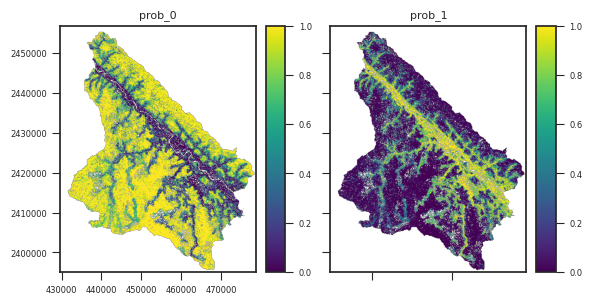

In [105]:
result_rf.plot() # Plot the resulting landslide susceptibility map
plt.show()

Saving the result as a .tif file

In [107]:
result_rf.write(r'/workspace/LSM/probability_rf_VY.tif') # Save the RF susceptibility map as a GeoTIFF for the VY area

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_rf_VY.tif, /worksp...
2        rows                                               4942
3        cols                                               3932
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


Repeating it with LR

In [108]:
result_lr = stack.predict_proba(estimator=model_lr) # Predict landslide probability for the VY area using LR model

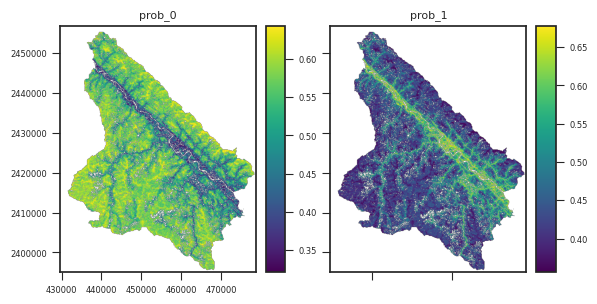

In [109]:
result_lr.plot() # Plot the LR susceptibility map
plt.show()

In [110]:
result_lr.write(r'/workspace/LSM/probability_lr_VY.tif') # Save the LR susceptibility map as a GeoTIFF for the VY area

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_lr_VY.tif, /worksp...
2        rows                                               4942
3        cols                                               3932
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


and SVM

In [111]:
result_svm = stack.predict_proba(estimator=model_svm) # Predict landslide probability for the VY area using SVM model

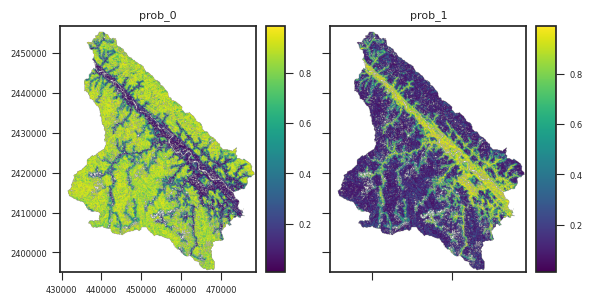

In [112]:
result_svm.plot() # Plot the SVM susceptibility map
plt.show()

In [113]:
result_svm.write(r'/workspace/LSM/probability_svm_VY.tif') # Save the SVM susceptibility map as a GeoTIFF for the VY area

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_svm_VY.tif, /works...
2        rows                                               4942
3        cols                                               3932
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


and XGBoost

In [114]:
# Predicting probability with trained XGBoost classifier
result_xgb = stack.predict_proba(estimator=model_xgb) # Predict landslide probability for the VY area using XGBoost model

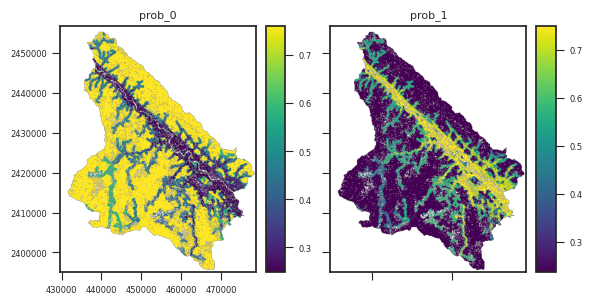

In [115]:
# Plotting probabilities
result_xgb.plot() # Plot the XGBoost susceptibility map for the MCC area
plt.show()

In [117]:
result_xgb.write(r'/workspace/LSM/probability_xgb_VY.tif') # Save the XGBoost susceptibility map as a GeoTIFF for the MCC area

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_xgb_VY.tif, /works...
2        rows                                               4942
3        cols                                               3932
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


## LSM of validation area

Predicting probability with trained RF classifier

In [145]:
result_rf = stack_val.predict_proba(estimator=model_rf)

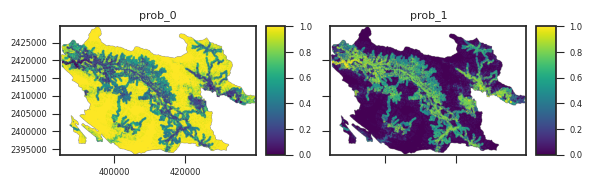

In [146]:
result_rf.plot()
plt.show()

In [147]:
##Saving the result as a .tif file

In [148]:
result_rf.write(r'/workspace/LSM/probability_rf_MCC.tif')

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_rf_MCC.tif, /works...
2        rows                                               2896
3        cols                                               4413
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


In [149]:
##SVM

In [150]:
result_svm = stack_val.predict_proba(estimator=model_svm)

In [151]:
result_svm.write(r'/workspace/LSM/probability_SVM_MCC.tif')

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_SVM_MCC.tif, /work...
2        rows                                               2896
3        cols                                               4413
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


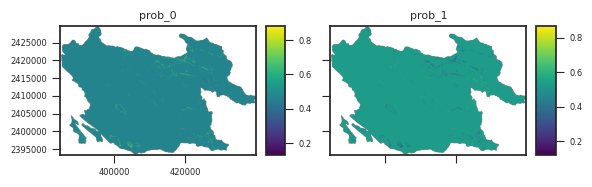

In [152]:
result_svm.plot()
plt.show()

In [153]:
##LR

In [154]:
result_lr = stack_val.predict_proba(estimator=model_lr)

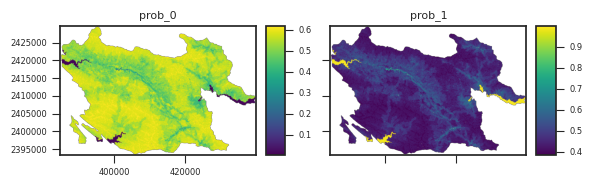

In [155]:
result_lr.plot()
plt.show()

In [156]:
result_lr.write(r'/workspace/LSM/probability_lr_MCC.tif')

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_lr_MCC.tif, /works...
2        rows                                               2896
3        cols                                               4413
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


In [157]:
## XGBoost

In [158]:
result_xgb = stack_val.predict_proba(estimator=model_xgb)

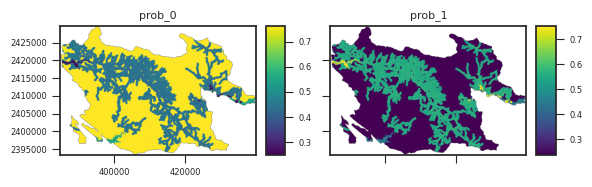

In [159]:
# Plotting probabilities
result_xgb.plot()
plt.show()

In [160]:
result_xgb.write(r'/workspace/LSM/probability_xgb_MCC.tif')

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [/workspace/LSM/probability_xgb_MCC.tif, /work...
2        rows                                               2896
3        cols                                               4413
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


End.